# 03 — Business Insights & Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/cleaned_data.csv')
print(df.shape)


(100000, 17)


## Q1 — Does delivery time drive ratings?

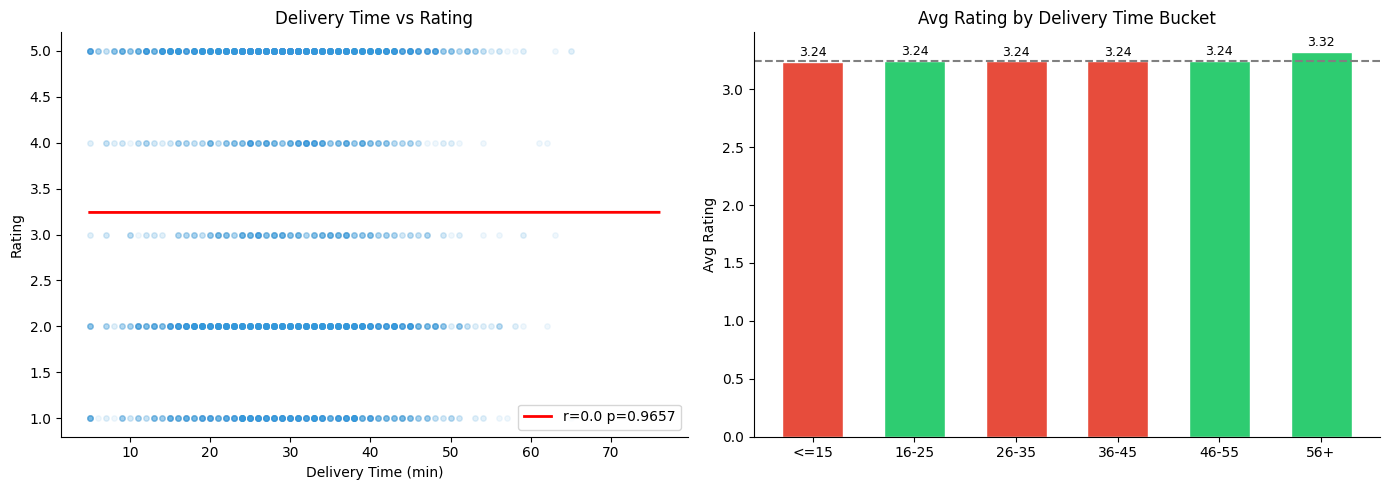

r = 0.0001   p = 0.965723   Direction: Positive


In [2]:
# scatter + binned average
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['Delivery Time (Minutes)'], sample['Service Rating'],
                alpha=0.07, color='#3498DB', s=15)

m, b, r, p, _ = stats.linregress(df['Delivery Time (Minutes)'], df['Service Rating'])
x = np.linspace(5, 76, 100)
axes[0].plot(x, m*x+b, color='red', lw=2, label='r='+str(round(r,3))+' p='+str(round(p,4)))
axes[0].set_title('Delivery Time vs Rating')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Rating')
axes[0].legend()

bins   = [0, 15, 25, 35, 45, 55, 76]
labels = ['<=15','16-25','26-35','36-45','46-55','56+']
df['Bin'] = pd.cut(df['Delivery Time (Minutes)'], bins=bins, labels=labels)
binned = df.groupby('Bin', observed=True)['Service Rating'].mean()
bar_colors = ['#2ECC71' if v >= df['Service Rating'].mean() else '#E74C3C' for v in binned.values]
axes[1].bar(binned.index.astype(str), binned.values, color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(df['Service Rating'].mean(), color='gray', linestyle='--')
axes[1].set_title('Avg Rating by Delivery Time Bucket')
axes[1].set_ylabel('Avg Rating')
for i, v in enumerate(binned.values): axes[1].text(i, v+0.05, str(round(v,2)), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/05_deliverytime_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

direction = 'Negative (longer = lower rating)' if r < 0 else 'Positive'
print("r =", round(r,4), "  p =", round(p,6), "  Direction:", direction)


## Q2 — Delay full impact

In [3]:
delay_stats = df.groupby('Delivery Delay').agg(
    Avg_Rating  = ('Service Rating', 'mean'),
    Refund_Rate = ('Refund_Flag', 'mean'),
    Revenue     = ('Order Value (INR)', 'sum')
).round(3)

print(delay_stats)
rating_drop = round(delay_stats.loc['No','Avg_Rating'] - delay_stats.loc['Yes','Avg_Rating'], 2)
mult        = round(delay_stats.loc['Yes','Refund_Rate'] / delay_stats.loc['No','Refund_Rate'], 2)
print("\nRating drop due to delay:", rating_drop)
print("Refund multiplier:", mult, "x")


                Avg_Rating  Refund_Rate   Revenue
Delivery Delay                                   
No                   3.242        0.458  50980613
Yes                  3.230        0.461   8118827

Rating drop due to delay: 0.01
Refund multiplier: 1.01 x


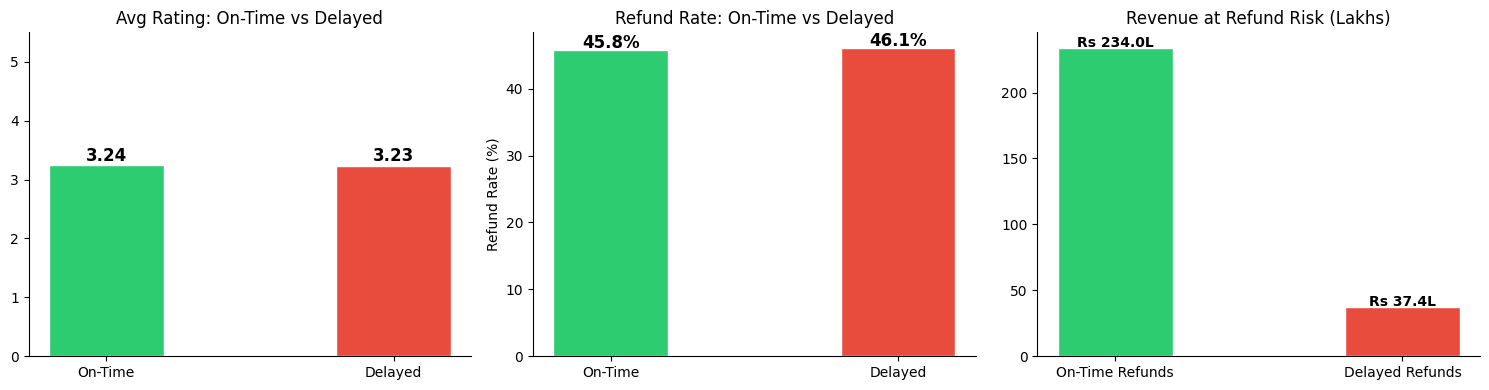

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
groups = ['On-Time', 'Delayed']
gc     = ['#2ECC71', '#E74C3C']

axes[0].bar(groups, delay_stats['Avg_Rating'].values, color=gc, edgecolor='white', width=0.4)
axes[0].set_title('Avg Rating: On-Time vs Delayed')
axes[0].set_ylim(0, 5.5)
for i, v in enumerate(delay_stats['Avg_Rating'].values):
    axes[0].text(i, v+0.08, str(round(v,2)), ha='center', fontweight='bold', fontsize=12)

refund_vals = delay_stats['Refund_Rate'].values * 100
axes[1].bar(groups, refund_vals, color=gc, edgecolor='white', width=0.4)
axes[1].set_title('Refund Rate: On-Time vs Delayed')
axes[1].set_ylabel('Refund Rate (%)')
for i, v in enumerate(refund_vals):
    axes[1].text(i, v+0.3, str(round(v,1))+'%', ha='center', fontweight='bold', fontsize=12)

rev_risk_no  = df[(df['Delivery Delay']=='No')  & (df['Refund_Flag']==1)]['Order Value (INR)'].sum()
rev_risk_yes = df[(df['Delivery Delay']=='Yes') & (df['Refund_Flag']==1)]['Order Value (INR)'].sum()
risk_labels = ['On-Time Refunds', 'Delayed Refunds']
axes[2].bar(risk_labels,
            [rev_risk_no/1e5, rev_risk_yes/1e5], color=gc, edgecolor='white', width=0.4)
axes[2].set_title('Revenue at Refund Risk (Lakhs)')
for i, v in enumerate([rev_risk_no/1e5, rev_risk_yes/1e5]):
    axes[2].text(i, v+0.5, 'Rs '+str(round(v,1))+'L', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/06_delay_impact.png', dpi=150, bbox_inches='tight')
plt.show()


## Q3 — Category Risk Heatmap

                     Delay_Pct  Refund_Pct  Avg_Del_Min  Avg_Rating
Product Category                                                   
Beverages                 13.5        45.7        29.50        3.25
Dairy                     13.7        45.6        29.56        3.24
Fruits & Vegetables       13.8        46.2        29.55        3.23
Grocery                   13.8        46.7        29.58        3.22
Personal Care             13.6        45.5        29.57        3.25
Snacks                    13.6        45.2        29.45        3.25


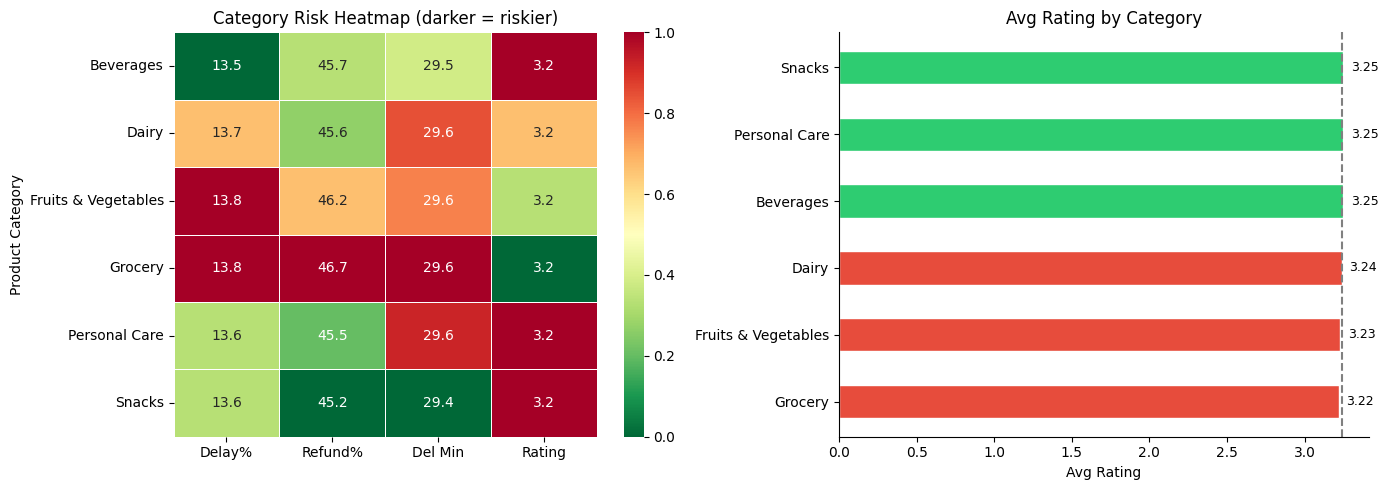

In [7]:
cat_risk = df.groupby('Product Category').agg(
    Delay_Pct   = ('Delay_Flag',               lambda x: round(x.mean()*100, 1)),
    Refund_Pct  = ('Refund_Flag',              lambda x: round(x.mean()*100, 1)),
    Avg_Del_Min = ('Delivery Time (Minutes)',  'mean'),
    Avg_Rating  = ('Service Rating',           'mean')
).round(2)

print(cat_risk)

norm = (cat_risk - cat_risk.min()) / (cat_risk.max() - cat_risk.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(norm, annot=cat_risk.round(1), fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Category Risk Heatmap (darker = riskier)')
axes[0].set_xticklabels(['Delay%','Refund%','Del Min','Rating'], rotation=0)

cat_r = cat_risk['Avg_Rating'].sort_values()
colors = ['#E74C3C' if v < df['Service Rating'].mean() else '#2ECC71' for v in cat_r.values]
axes[1].barh(cat_r.index, cat_r.values, color=colors, edgecolor='white', height=0.5)
axes[1].axvline(df['Service Rating'].mean(), color='gray', linestyle='--')
axes[1].set_title('Avg Rating by Category')
axes[1].set_xlabel('Avg Rating')
for i, v in enumerate(cat_r.values):
    axes[1].text(v+0.05, i, str(round(v,2)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/07_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Q4 — Revenue by Category

In [8]:
rev = df.groupby('Product Category').agg(
    Revenue = ('Order Value (INR)', 'sum'),
    Orders  = ('Order ID',          'count')
).sort_values('Revenue', ascending=False).reset_index()

rev['Share'] = (rev['Revenue'] / rev['Revenue'].sum() * 100).round(1)
rev['AOV']   = (rev['Revenue'] / rev['Orders']).round(0)
print(rev)


      Product Category   Revenue  Orders  Share     AOV
0        Personal Care  17395601   16533   29.4  1052.0
1              Grocery  14194055   16737   24.0   848.0
2            Beverages   9086669   16536   15.4   550.0
3                Dairy   7610522   16857   12.9   451.0
4  Fruits & Vegetables   6246517   16632   10.6   376.0
5               Snacks   4566076   16705    7.7   273.0


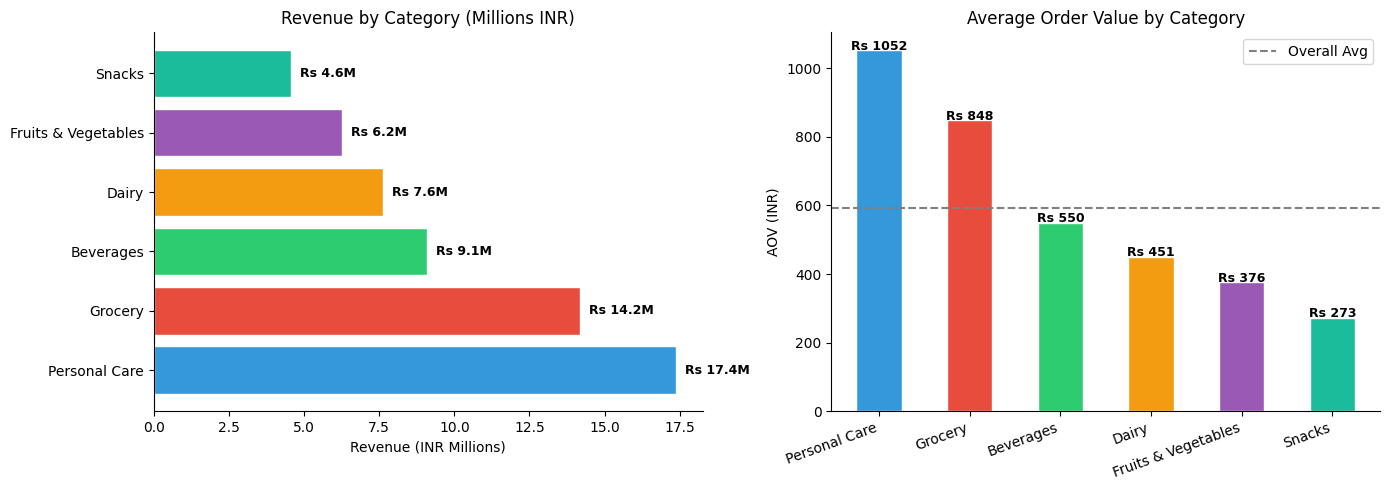

In [9]:
CAT_COLS = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(rev['Product Category'], rev['Revenue']/1e6,
             color=CAT_COLS, edgecolor='white')
axes[0].set_title('Revenue by Category (Millions INR)')
axes[0].set_xlabel('Revenue (INR Millions)')
for i, v in enumerate(rev['Revenue'].values/1e6):
    axes[0].text(v+0.3, i, 'Rs '+str(round(v,1))+'M', va='center', fontsize=9, fontweight='bold')

axes[1].bar(rev['Product Category'], rev['AOV'],
            color=CAT_COLS, edgecolor='white', width=0.5)
axes[1].set_title('Average Order Value by Category')
axes[1].set_ylabel('AOV (INR)')
axes[1].set_xticklabels(rev['Product Category'], rotation=20, ha='right')
for i, v in enumerate(rev['AOV'].values):
    axes[1].text(i, v+2, 'Rs '+str(int(v)), ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(df['Order Value (INR)'].mean(), color='gray', linestyle='--', label='Overall Avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/08_revenue_category.png', dpi=150, bbox_inches='tight')
plt.show()


## Hypothesis Testing

In [10]:
on_time  = df[df['Delivery Delay'] == 'No']['Service Rating']
delayed  = df[df['Delivery Delay'] == 'Yes']['Service Rating']

t1, p1 = stats.ttest_ind(on_time, delayed, equal_var=False)

print("=== H1: Delays reduce ratings ===")
print("On-Time mean:", round(on_time.mean(), 3))
print("Delayed mean:", round(delayed.mean(), 3))
print("T-stat:", round(t1, 4), "  P-value:", round(p1, 6))
print("Significant?" , "YES" if p1 < 0.05 else "NO")

on_ref  = df[df['Delivery Delay'] == 'No']['Refund_Flag']
del_ref = df[df['Delivery Delay'] == 'Yes']['Refund_Flag']
t2, p2  = stats.ttest_ind(on_ref, del_ref, equal_var=False)

print("\n=== H2: Delays increase refund rate ===")
print("On-Time refund rate:", round(on_ref.mean()*100, 2), "%")
print("Delayed refund rate:", round(del_ref.mean()*100, 2), "%")
print("T-stat:", round(t2, 4), "  P-value:", round(p2, 6))
print("Significant?" , "YES" if p2 < 0.05 else "NO")


=== H1: Delays reduce ratings ===
On-Time mean: 3.242
Delayed mean: 3.23
T-stat: 0.8305   P-value: 0.406288
Significant? NO

=== H2: Delays increase refund rate ===
On-Time refund rate: 45.78 %
Delayed refund rate: 46.06 %
T-stat: -0.621   P-value: 0.534618
Significant? NO


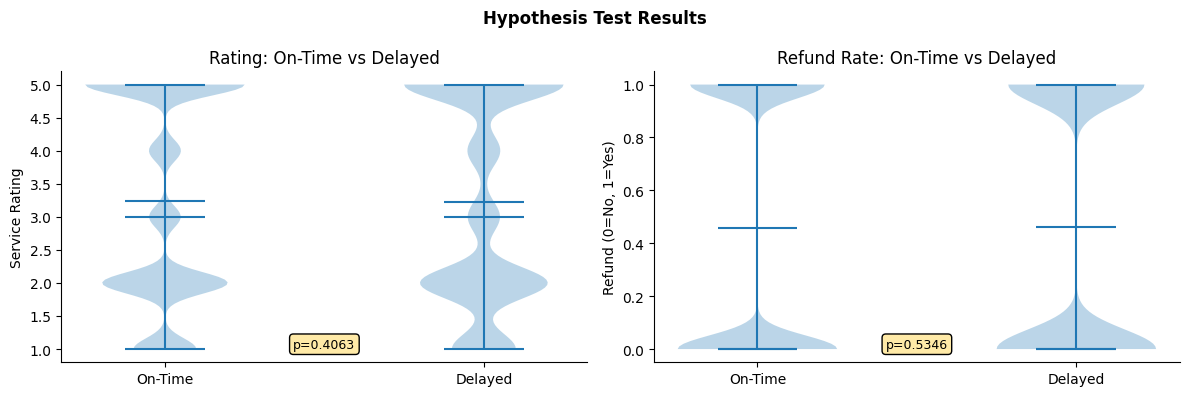

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Hypothesis Test Results', fontweight='bold')

axes[0].violinplot([on_time, delayed], positions=[1, 2], showmedians=True, showmeans=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['On-Time', 'Delayed'])
axes[0].set_title('Rating: On-Time vs Delayed')
axes[0].set_ylabel('Service Rating')
label1 = 'p=' + str(round(p1,4)) + (' *** Significant' if p1 < 0.05 else '')
axes[0].text(0.5, 0.05, label1, transform=axes[0].transAxes, ha='center',
             bbox=dict(boxstyle='round', facecolor='#FFEAA7'), fontsize=9)

axes[1].violinplot([on_ref, del_ref], positions=[1, 2], showmedians=True, showmeans=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['On-Time', 'Delayed'])
axes[1].set_title('Refund Rate: On-Time vs Delayed')
axes[1].set_ylabel('Refund (0=No, 1=Yes)')
label2 = 'p=' + str(round(p2,4)) + (' *** Significant' if p2 < 0.05 else '')
axes[1].text(0.5, 0.05, label2, transform=axes[1].transAxes, ha='center',
             bbox=dict(boxstyle='round', facecolor='#FFEAA7'), fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/09_hypothesis_tests.png', dpi=150, bbox_inches='tight')
plt.show()
